# Inverse Planning Demo

This notebook demonstrates the working `memo`-backed inverse-planning pipeline on the default `8x8` gridworld with `3` candidate goals. It covers four concrete steps: inspect the grid, run a few hand-picked scenarios, generate datasets with multiple settings, and train the RNN baselines.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from dataclasses import replace
from pathlib import Path
from IPython.display import HTML, SVG, display

from inverse_planning.data import collect_dataset, encode_grid_frame, save_dataset
from inverse_planning.inference import (
    exact_goal_posterior,
    online_goal_posteriors,
    online_posteriors_from_goal_conditioned_action_probs,
    posterior_from_goal_conditioned_scores,
    score_goal_conditioned_policy,
)
from inverse_planning.memo_backend import MemoPolicyBackend
from inverse_planning.rnn_models import ModelFactory
from inverse_planning.simulate import sample_trajectory
from inverse_planning.task import make_default_task
from inverse_planning.training import (
    TrainingConfig,
    build_classifier_loader,
    build_policy_loader,
    evaluate_classifier,
    evaluate_policy_model,
    train_classifier,
    train_policy_model,
)
from inverse_planning.visualize import render_gridworld_svg, render_trajectory_frames_html

task = make_default_task(beta=2.0)
memo_backend = MemoPolicyBackend(task)
memo_backend.build()
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

print('task shape:', task.shape)
print('goals:', task.goal_locs)
print('training device:', device)

MODEL_STYLES = {
    'action_gru': {'label': 'Action-GRU', 'color': '#1b9e77', 'marker': 'o'},
    'conv_gru': {'label': 'Conv-GRU', 'color': '#d95f02', 'marker': '^'},
    'goal_conditioned_policy': {'label': 'Goal-Conditioned Policy', 'color': '#7570b3', 'marker': 's'},
}

BETA_STYLES = {
    0.75: {'label': 'beta = 0.75', 'color': '#66a61e', 'marker': 'o'},
    1.5: {'label': 'beta = 1.5', 'color': '#e6ab02', 'marker': '^'},
    3.0: {'label': 'beta = 3.0', 'color': '#a6761d', 'marker': 's'},
}

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.frameon': False,
})


task shape: (8, 8)
goals: ((0, 0), (0, 7), (7, 7))
training device: cuda:0


## 1. Grid And Baseline Trajectory

Start by visualizing the default gridworld and one sampled memo-planned trajectory. The exact observer posterior is computed from the action sequence.


initial location: (7, 0)
[[0 0 0 0 1 0 0 0]
 [0 1 1 0 1 0 1 0]
 [0 0 0 0 0 0 1 0]
 [1 1 0 1 1 0 0 0]
 [0 0 0 0 0 1 1 0]
 [0 1 1 1 0 0 0 0]
 [0 0 0 1 0 1 1 0]
 [0 1 0 0 0 0 0 0]]


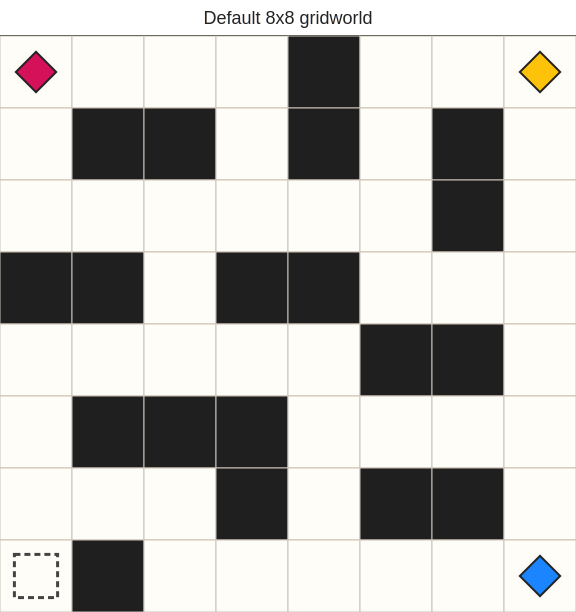

sampled goal index: 2
sampled actions: [1, 0, 0, 4, 4, 2, 4, 4, 4, 4, 0, 4]
final exact posterior: [0.    0.005 0.995]


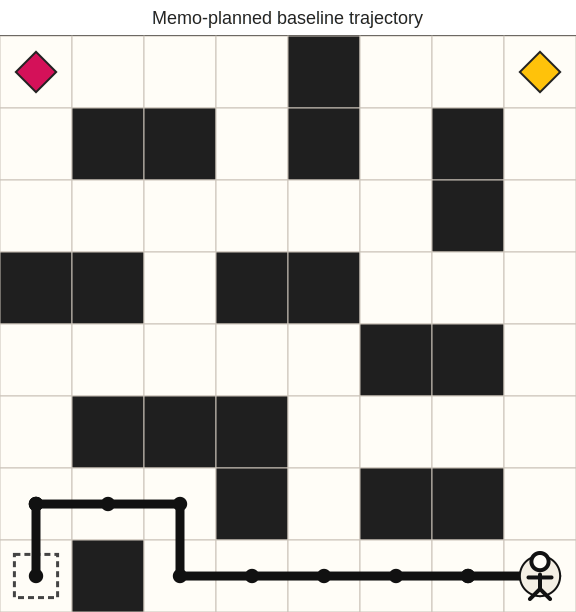

online exact posterior:
[[0.333 0.333 0.333]
 [0.333 0.333 0.333]
 [0.333 0.333 0.333]
 [0.018 0.018 0.965]
 [0.    0.01  0.99 ]
 [0.    0.01  0.99 ]
 [0.    0.01  0.99 ]
 [0.    0.01  0.99 ]
 [0.    0.005 0.995]
 [0.    0.005 0.995]
 [0.    0.005 0.995]
 [0.    0.005 0.995]]


In [11]:
print('initial location:', task.init_loc)
print(task.grid.astype(int))
display(SVG(render_gridworld_svg(task, cell_size=72, title='Default 8x8 gridworld')))

baseline = sample_trajectory(task, horizon=12, rng=np.random.default_rng(0), policy_backend=memo_backend)
baseline_posterior = exact_goal_posterior(task, baseline.action_indices, policy_backend=memo_backend)
baseline_online = online_goal_posteriors(task, baseline.action_indices, policy_backend=memo_backend)

print('sampled goal index:', baseline.goal_index)
print('sampled actions:', baseline.action_indices)
print('final exact posterior:', np.round(baseline_posterior, 3))
display(SVG(render_gridworld_svg(task, trajectory=baseline, cell_size=72, title='Memo-planned baseline trajectory')))
print('online exact posterior:')
print(np.round(baseline_online, 3))


## 2. Scenario Walkthroughs

Demonstrate inverse planning on several concrete scenarios. Each scenario changes the start location and fixes the intended goal so the qualitative posterior updates are easy to inspect.


Northwest chase: start=(7, 0) goal=(0, 0)
  actions: [1, 1, 1, 4, 4, 1, 0, 1, 3, 3, 1, 1]
  final posterior: [1. 0. 0.]


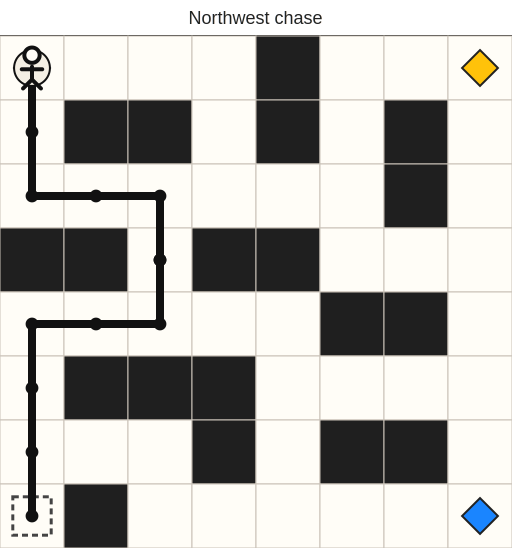

  online posterior:
[[0.333 0.333 0.333]
 [0.495 0.495 0.009]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.5   0.5   0.   ]
 [0.982 0.018 0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]
 [1.    0.    0.   ]]
------------------------------------------------------------------------
Cross-map east goal: start=(4, 0) goal=(0, 7)
  actions: [2, 1, 4, 0, 4, 1, 0, 1, 4, 4, 4, 1, 1, 4]
  final posterior: [0. 1. 0.]


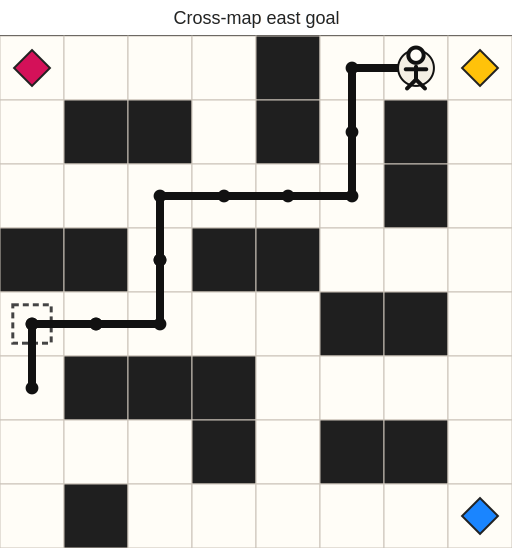

  online posterior:
[[0.032 0.032 0.937]
 [0.394 0.394 0.213]
 [0.436 0.436 0.127]
 [0.436 0.436 0.127]
 [0.436 0.436 0.127]
 [0.499 0.499 0.003]
 [0.499 0.499 0.003]
 [0.5   0.5   0.   ]
 [0.018 0.982 0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]]
------------------------------------------------------------------------
Bottom-right commitment: start=(6, 2) goal=(7, 7)
  actions: [2, 4, 4, 4, 4, 4, 0, 0, 0, 0]
  final posterior: [0. 0. 1.]


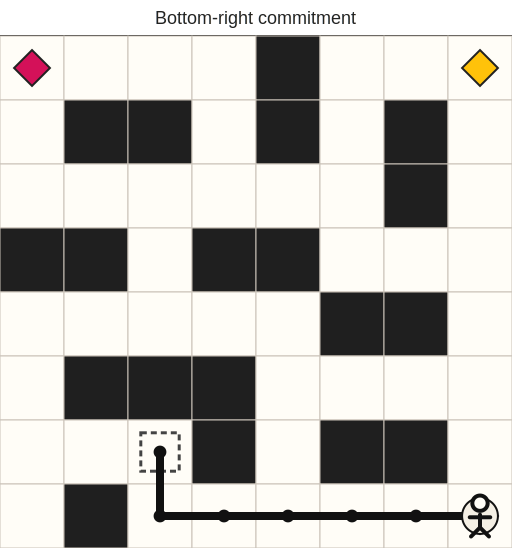

  online posterior:
[[0.009 0.495 0.495]
 [0.005 0.498 0.498]
 [0.005 0.498 0.498]
 [0.    0.352 0.648]
 [0.    0.352 0.648]
 [0.    0.352 0.648]
 [0.    0.075 0.925]
 [0.    0.012 0.988]
 [0.    0.002 0.998]
 [0.    0.    1.   ]]
------------------------------------------------------------------------


In [12]:
scenario_specs = [
    {'name': 'Northwest chase', 'init_loc': (7, 0), 'goal_index': 0, 'horizon': 12, 'seed': 7},
    {'name': 'Cross-map east goal', 'init_loc': (4, 0), 'goal_index': 1, 'horizon': 14, 'seed': 11},
    {'name': 'Bottom-right commitment', 'init_loc': (6, 2), 'goal_index': 2, 'horizon': 10, 'seed': 17},
]

scenario_runs = []
for spec in scenario_specs:
    scenario_task = replace(task, init_loc=spec['init_loc'])
    scenario_task.validate()
    trajectory = sample_trajectory(
        scenario_task,
        horizon=spec['horizon'],
        rng=np.random.default_rng(spec['seed']),
        goal_index=spec['goal_index'],
        policy_backend=memo_backend,
    )
    posterior = exact_goal_posterior(scenario_task, trajectory.action_indices, policy_backend=memo_backend)
    online = online_goal_posteriors(scenario_task, trajectory.action_indices, policy_backend=memo_backend)
    scenario_runs.append((spec, scenario_task, trajectory, posterior, online))
    print(f"{spec['name']}: start={spec['init_loc']} goal={scenario_task.goal_locs[spec['goal_index']]}")
    print('  actions:', trajectory.action_indices)
    print('  final posterior:', np.round(posterior, 3))
    display(SVG(render_gridworld_svg(scenario_task, trajectory=trajectory, cell_size=64, title=spec['name'])))
    print('  online posterior:')
    print(np.round(online, 3))
    print('-' * 72)


## 3. Dataset Budgets

Create several training sets with increasing episode counts, plus one fixed evaluation set. These saved datasets support both the main training run and a clean sample-efficiency study.


In [13]:
dataset_specs = [
    {'name': 'budget_64', 'episodes': 64, 'horizon': 12, 'seed': 1},
    {'name': 'budget_256', 'episodes': 256, 'horizon': 12, 'seed': 2},
    {'name': 'budget_1024', 'episodes': 1024, 'horizon': 12, 'seed': 3},
    {'name': 'budget_2048', 'episodes': 2048, 'horizon': 12, 'seed': 4},
    {'name': 'budget_4096', 'episodes': 4096, 'horizon': 12, 'seed': 5},
    {'name': 'eval_1024', 'episodes': 1024, 'horizon': 12, 'seed': 99},
]

dataset_registry = {}
for spec in dataset_specs:
    bundle = collect_dataset(
        task,
        n_episodes=spec['episodes'],
        horizon=spec['horizon'],
        seed=spec['seed'],
        policy_backend=memo_backend,
    )
    path = artifacts_dir / f"{spec['name']}.npz"
    save_dataset(path, bundle)
    dataset_registry[spec['name']] = {'spec': spec, 'path': path, 'bundle': bundle}
    print(spec['name'])
    print('  saved to:', path)
    print('  grids:', bundle.grids.shape)
    print('  actions:', bundle.actions.shape)
    print('  goals:', bundle.goals.shape)
    unique_goals, counts = np.unique(bundle.goals, return_counts=True)
    print('  goal counts:', dict(zip(unique_goals.tolist(), counts.tolist())))
    print()

train_name = 'budget_4096'
eval_name = 'eval_1024'
train_npz = np.load(dataset_registry[train_name]['path'])
eval_npz = np.load(dataset_registry[eval_name]['path'])
print('selected training dataset:', train_name)
print('held-out evaluation dataset:', eval_name)


budget_64
  saved to: artifacts/budget_64.npz
  grids: (64, 12, 6, 8, 8)
  actions: (64, 12)
  goals: (64,)
  goal counts: {0: 22, 1: 22, 2: 20}

budget_256
  saved to: artifacts/budget_256.npz
  grids: (256, 12, 6, 8, 8)
  actions: (256, 12)
  goals: (256,)
  goal counts: {0: 91, 1: 73, 2: 92}

budget_1024
  saved to: artifacts/budget_1024.npz
  grids: (1024, 12, 6, 8, 8)
  actions: (1024, 12)
  goals: (1024,)
  goal counts: {0: 348, 1: 351, 2: 325}

budget_2048
  saved to: artifacts/budget_2048.npz
  grids: (2048, 12, 6, 8, 8)
  actions: (2048, 12)
  goals: (2048,)
  goal counts: {0: 678, 1: 712, 2: 658}

budget_4096
  saved to: artifacts/budget_4096.npz
  grids: (4096, 12, 6, 8, 8)
  actions: (4096, 12)
  goals: (4096,)
  goal counts: {0: 1422, 1: 1355, 2: 1319}

eval_1024
  saved to: artifacts/eval_1024.npz
  grids: (1024, 12, 6, 8, 8)
  actions: (1024, 12)
  goals: (1024,)
  goal counts: {0: 328, 1: 349, 2: 347}

selected training dataset: budget_4096
held-out evaluation dataset: 

## 4. Main Training Run

Train all three models on the largest default budget and evaluate them on the fixed held-out split. This gives one strong reference point before the notebook branches into targeted experiments.


In [14]:
torch.manual_seed(0)

factory = ModelFactory(
    in_channels=train_npz['grids'].shape[2],
    n_actions=int(train_npz['actions'].max()) + 1,
    n_goals=train_npz['final_posteriors'].shape[-1],
)
config = TrainingConfig(batch_size=64, epochs=12, learning_rate=5e-4, device=device)

training_runs = {}
for variant in ['action_gru', 'conv_gru']:
    model = factory.build_classifier(variant)
    losses = train_classifier(model, build_classifier_loader(train_npz, batch_size=config.batch_size), config)
    metrics = evaluate_classifier(model, eval_npz, device=device)
    training_runs[variant] = {'model': model, 'losses': losses, 'metrics': metrics}
    torch.save(model.state_dict(), artifacts_dir / f'{variant}.pt')

policy_model = factory.build_policy_model()
policy_losses = train_policy_model(policy_model, build_policy_loader(train_npz, batch_size=config.batch_size), config)
policy_metrics = evaluate_policy_model(policy_model, eval_npz, device=device)
training_runs['goal_conditioned_policy'] = {'model': policy_model, 'losses': policy_losses, 'metrics': policy_metrics}
torch.save(policy_model.state_dict(), artifacts_dir / 'goal_conditioned_policy.pt')

for name, run in training_runs.items():
    print(name)
    print('  final loss:', round(run['losses'][-1], 4))
    print('  optimization steps:', len(run['losses']))
    print('  eval final-goal accuracy:', round(run['metrics']['final_goal_accuracy'], 4))
    print('  eval posterior KL:', round(run['metrics']['posterior_kl'], 4))


action_gru
  final loss: 1.1125
  optimization steps: 768
  eval final-goal accuracy: 0.9678
  eval posterior KL: 0.0916
conv_gru
  final loss: 1.2612
  optimization steps: 768
  eval final-goal accuracy: 0.9609
  eval posterior KL: 0.0953
goal_conditioned_policy
  final loss: 0.5262
  optimization steps: 768
  eval final-goal accuracy: 0.9824
  eval posterior KL: 0.0318


## 5. Inference Over Time By Data Budget

Measure how well each model matches the exact observer as more actions are observed. Each curve is an evaluation-set average of posterior KL at timestep `t`, so lower curves indicate faster and more accurate goal inference over time.


In [15]:
scaling_budgets = ['budget_64', 'budget_256', 'budget_1024', 'budget_2048', 'budget_4096']
scaling_config = TrainingConfig(batch_size=64, epochs=5, learning_rate=5e-4, device=device)
scaling_results = []

for budget_name in scaling_budgets:
    budget_npz = np.load(dataset_registry[budget_name]['path'])
    budget_factory = ModelFactory(
        in_channels=budget_npz['grids'].shape[2],
        n_actions=int(budget_npz['actions'].max()) + 1,
        n_goals=budget_npz['final_posteriors'].shape[-1],
    )
    for variant in ['action_gru', 'conv_gru', 'goal_conditioned_policy']:
        torch.manual_seed(0)
        if variant == 'goal_conditioned_policy':
            model = budget_factory.build_policy_model()
            losses = train_policy_model(model, build_policy_loader(budget_npz, batch_size=scaling_config.batch_size), scaling_config)
            metrics = evaluate_policy_model(model, eval_npz, device=device)
        else:
            model = budget_factory.build_classifier(variant)
            losses = train_classifier(model, build_classifier_loader(budget_npz, batch_size=scaling_config.batch_size), scaling_config)
            metrics = evaluate_classifier(model, eval_npz, device=device)
        scaling_results.append({
            'budget_name': budget_name,
            'episodes': int(dataset_registry[budget_name]['spec']['episodes']),
            'variant': variant,
            'final_loss': float(losses[-1]),
            'posterior_kl': metrics['posterior_kl'],
            'posterior_kl_by_step': metrics['posterior_kl_by_step'],
        })

for row in scaling_results:
    print(f"{row['budget_name']:>11} | {row['variant']:<24} | mean KL = {row['posterior_kl']:.4f}")


  budget_64 | action_gru               | mean KL = 0.6340
  budget_64 | conv_gru                 | mean KL = 0.6510
  budget_64 | goal_conditioned_policy  | mean KL = 0.5908
 budget_256 | action_gru               | mean KL = 0.4675
 budget_256 | conv_gru                 | mean KL = 0.5141
 budget_256 | goal_conditioned_policy  | mean KL = 0.2800
budget_1024 | action_gru               | mean KL = 0.1460
budget_1024 | conv_gru                 | mean KL = 0.1685
budget_1024 | goal_conditioned_policy  | mean KL = 0.0478
budget_2048 | action_gru               | mean KL = 0.1201
budget_2048 | conv_gru                 | mean KL = 0.1298
budget_2048 | goal_conditioned_policy  | mean KL = 0.0556
budget_4096 | action_gru               | mean KL = 0.1012
budget_4096 | conv_gru                 | mean KL = 0.1095
budget_4096 | goal_conditioned_policy  | mean KL = 0.0586


## 6. Goal Inference Over Time

Each panel corresponds to one training-data budget. The y-axis is held-out posterior KL, averaged over episodes at each timestep. Lower values mean the model stays closer to the exact inverse-planning posterior as evidence accumulates over time.


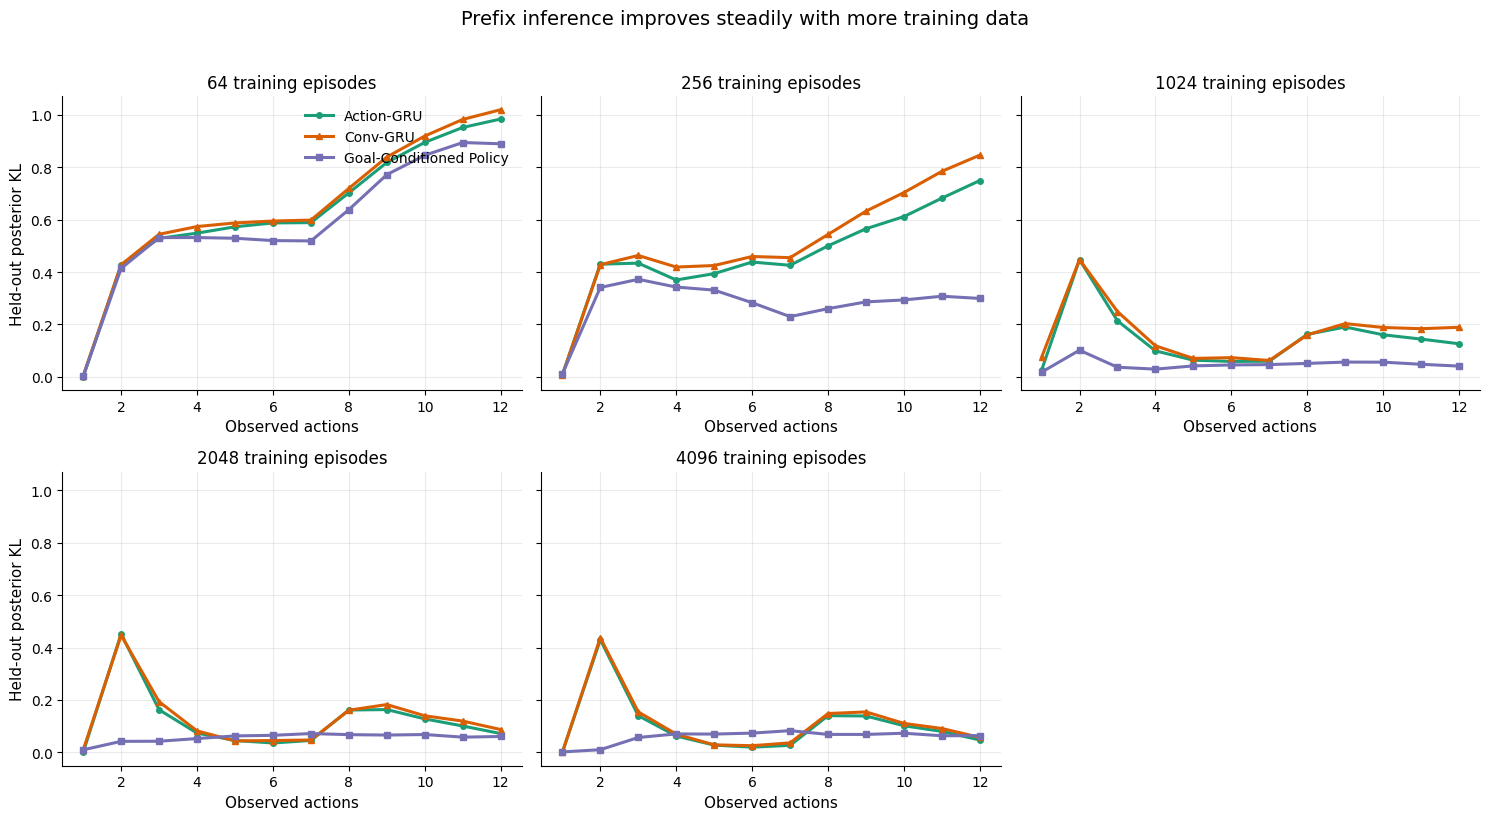

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()
for ax, budget_name in zip(axes, scaling_budgets):
    rows = [row for row in scaling_results if row['budget_name'] == budget_name]
    rows = sorted(rows, key=lambda row: row['episodes'])
    for row in rows:
        style = MODEL_STYLES[row['variant']]
        timesteps = np.arange(1, len(row['posterior_kl_by_step']) + 1)
        ax.plot(
            timesteps,
            row['posterior_kl_by_step'],
            marker=style['marker'],
            markersize=4,
            linewidth=2.2,
            color=style['color'],
            label=style['label'],
        )
    n_eps = dataset_registry[budget_name]['spec']['episodes']
    ax.set_title(f'{n_eps} training episodes')
    ax.set_xlabel('Observed actions')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Held-out posterior KL')
axes[3].set_ylabel('Held-out posterior KL')
axes[0].legend(loc='upper right', ncol=1)
if len(axes) > len(scaling_budgets):
    for ax in axes[len(scaling_budgets):]:
        ax.axis('off')
fig.suptitle('Goal inference improves steadily with more training data', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## 7. Rationality Ablation

Vary the planner rationality parameter `beta` while keeping the grid and candidate goals fixed. Lower `beta` produces noisier behavior, which should make inverse planning harder.


In [17]:
beta_values = [0.75, 1.5, 3.0]
beta_train_episodes = 1024
beta_eval_episodes = 512
beta_results = []

for beta in beta_values:
    beta_task = make_default_task(beta=beta)
    beta_backend = MemoPolicyBackend(beta_task)
    beta_backend.build()
    beta_train = collect_dataset(beta_task, n_episodes=beta_train_episodes, horizon=12, seed=int(beta * 100), policy_backend=beta_backend)
    beta_eval = collect_dataset(beta_task, n_episodes=beta_eval_episodes, horizon=12, seed=1000 + int(beta * 100), policy_backend=beta_backend)

    beta_train_path = artifacts_dir / f'beta_{str(beta).replace(".", "p")}_train.npz'
    beta_eval_path = artifacts_dir / f'beta_{str(beta).replace(".", "p")}_eval.npz'
    save_dataset(beta_train_path, beta_train)
    save_dataset(beta_eval_path, beta_eval)
    beta_train_npz = np.load(beta_train_path)
    beta_eval_npz = np.load(beta_eval_path)
    beta_factory = ModelFactory(
        in_channels=beta_train_npz['grids'].shape[2],
        n_actions=int(beta_train_npz['actions'].max()) + 1,
        n_goals=beta_train_npz['final_posteriors'].shape[-1],
    )
    beta_config = TrainingConfig(batch_size=64, epochs=5, learning_rate=5e-4, device=device)

    for variant in ['action_gru', 'conv_gru', 'goal_conditioned_policy']:
        torch.manual_seed(0)
        if variant == 'goal_conditioned_policy':
            model = beta_factory.build_policy_model()
            losses = train_policy_model(model, build_policy_loader(beta_train_npz, batch_size=beta_config.batch_size), beta_config)
            metrics = evaluate_policy_model(model, beta_eval_npz, device=device)
        else:
            model = beta_factory.build_classifier(variant)
            losses = train_classifier(model, build_classifier_loader(beta_train_npz, batch_size=beta_config.batch_size), beta_config)
            metrics = evaluate_classifier(model, beta_eval_npz, device=device)
        beta_results.append({
            'beta': beta,
            'variant': variant,
            'posterior_kl': metrics['posterior_kl'],
            'posterior_kl_by_step': metrics['posterior_kl_by_step'],
            'final_loss': float(losses[-1]),
        })

for row in beta_results:
    print(f"beta={row['beta']:<4} | {row['variant']:<24} | mean KL = {row['posterior_kl']:.4f}")


beta=0.75 | action_gru               | mean KL = 0.0658
beta=0.75 | conv_gru                 | mean KL = 0.0844
beta=0.75 | goal_conditioned_policy  | mean KL = 0.0627
beta=1.5  | action_gru               | mean KL = 0.1366
beta=1.5  | conv_gru                 | mean KL = 0.1569
beta=1.5  | goal_conditioned_policy  | mean KL = 0.0919
beta=3.0  | action_gru               | mean KL = 0.1314
beta=3.0  | conv_gru                 | mean KL = 0.1556
beta=3.0  | goal_conditioned_policy  | mean KL = 0.0226


## 8. Rationality Curves

These curves show how posterior quality changes when the acting agent is less or more rational. Lower `beta` means noisier action choices, so the inference problem should stay ambiguous for longer prefixes.


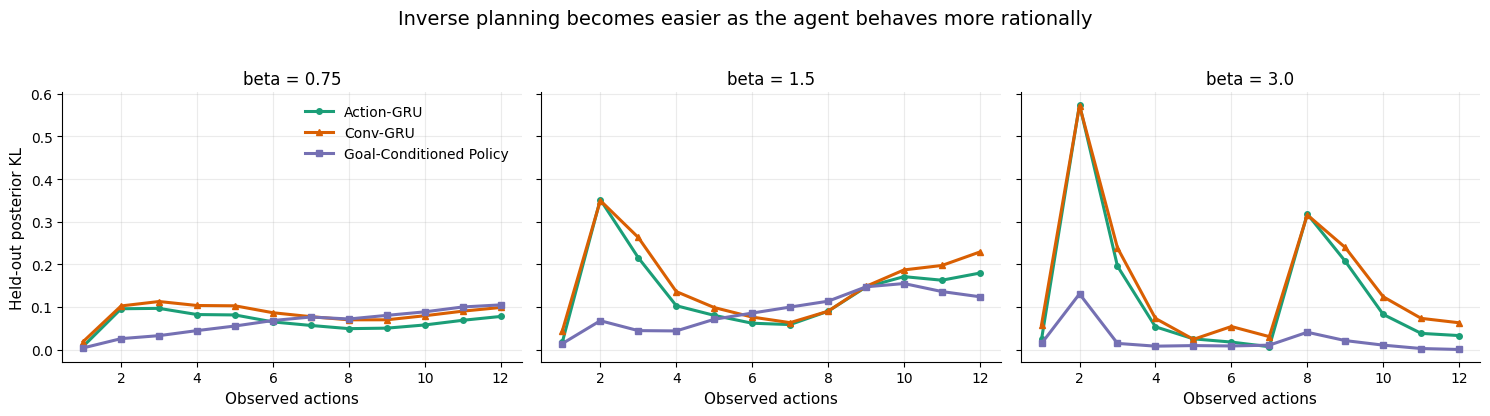

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, beta in zip(axes, beta_values):
    rows = [row for row in beta_results if row['beta'] == beta]
    for row in rows:
        style = MODEL_STYLES[row['variant']]
        timesteps = np.arange(1, len(row['posterior_kl_by_step']) + 1)
        ax.plot(
            timesteps,
            row['posterior_kl_by_step'],
            marker=style['marker'],
            markersize=4,
            linewidth=2.2,
            color=style['color'],
            label=style['label'],
        )
    ax.set_title(BETA_STYLES[beta]['label'])
    ax.set_xlabel('Observed actions')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Held-out posterior KL')
axes[0].legend(loc='upper right')
fig.suptitle('Inverse planning becomes easier as the agent behaves more rationally', y=1.03, fontsize=14)
fig.tight_layout()
plt.show()


## 9. Held-Out Trajectory Comparison

Return to one held-out trajectory from the default task and compare the exact posterior path against the models trained on the largest dataset.


held-out goal index: 0
held-out actions: [1, 1, 0, 1, 4, 4, 0, 1, 1, 3, 3, 4]
exact final posterior: [0.982 0.018 0.   ]
action-gru final belief: [0.998 0.001 0.   ]
conv-gru final belief: [0.999 0.001 0.   ]
goal-conditioned policy posterior: [0.998 0.002 0.   ]


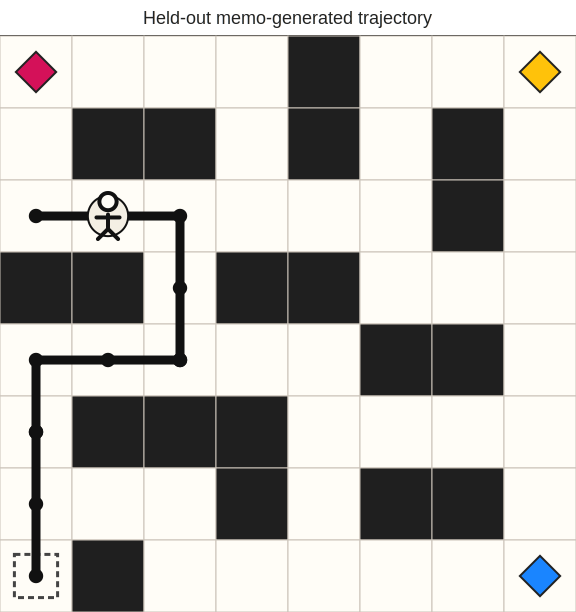

In [19]:
heldout = sample_trajectory(task, horizon=12, rng=np.random.default_rng(21), policy_backend=memo_backend)
heldout_exact = online_goal_posteriors(task, heldout.action_indices, policy_backend=memo_backend)

frames = np.stack(
    [encode_grid_frame(task, position=heldout.positions[step], step=step, horizon=len(heldout.action_indices)) for step in range(len(heldout.action_indices))],
    axis=0,
)[None]
prev_actions = np.full((1, len(heldout.action_indices)), task.n_actions, dtype=np.int64)
prev_actions[0, 1:] = np.asarray(heldout.action_indices[:-1], dtype=np.int64)
action_indices = np.asarray(heldout.action_indices, dtype=np.int64)

frames_t = torch.tensor(frames, dtype=torch.float32, device=device)
prev_actions_t = torch.tensor(prev_actions, dtype=torch.long, device=device)

for run in training_runs.values():
    run['model'].eval()
    run['model'].to(device)

with torch.no_grad():
    action_gru_out = training_runs['action_gru']['model'](frames_t, prev_actions_t)
    conv_gru_out = training_runs['conv_gru']['model'](frames_t, prev_actions_t)

action_gru_final = torch.softmax(action_gru_out['goal_logits'], dim=-1)[0].detach().cpu().numpy()
conv_gru_final = torch.softmax(conv_gru_out['goal_logits'], dim=-1)[0].detach().cpu().numpy()
action_gru_online = torch.softmax(action_gru_out['posterior_logits'], dim=-1)[0].detach().cpu().numpy()
conv_gru_online = torch.softmax(conv_gru_out['posterior_logits'], dim=-1)[0].detach().cpu().numpy()

policy_action_probabilities = []
policy_scores = []
with torch.no_grad():
    for goal_index in range(task.n_goals):
        goal_ids = torch.tensor([goal_index], dtype=torch.long, device=device)
        logits = training_runs['goal_conditioned_policy']['model'](frames_t, goal_ids, prev_actions_t)
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
        policy_action_probabilities.append(probs)
        policy_scores.append(score_goal_conditioned_policy(probs, action_indices))
policy_action_probabilities = np.asarray(policy_action_probabilities)
policy_posterior = posterior_from_goal_conditioned_scores(np.asarray(policy_scores))
policy_online = online_posteriors_from_goal_conditioned_action_probs(policy_action_probabilities, action_indices)

print('held-out goal index:', heldout.goal_index)
print('held-out actions:', heldout.action_indices)
print('exact final posterior:', np.round(heldout_exact[-1], 3))
print('action-gru final belief:', np.round(action_gru_final, 3))
print('conv-gru final belief:', np.round(conv_gru_final, 3))
print('goal-conditioned policy posterior:', np.round(policy_posterior, 3))

display(SVG(render_gridworld_svg(task, trajectory=heldout, cell_size=72, title='Held-out memo-generated trajectory')))


## 10. Posterior Curves For One Trajectory

The curves below show the exact posterior and learned approximations on a single held-out sequence. Unlike the aggregate prefix plots above, these are useful for qualitative inspection of where the models change their minds.


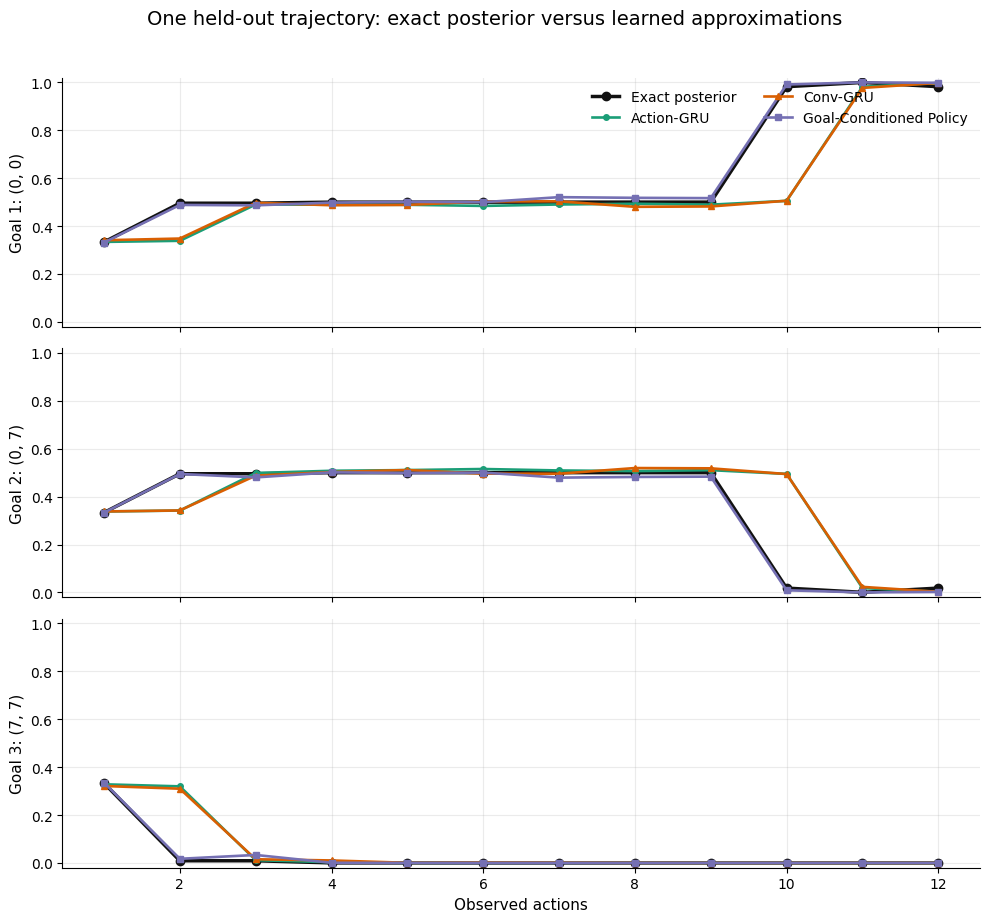

In [20]:
timesteps = np.arange(1, len(heldout.action_indices) + 1)
goal_labels = [f'Goal {idx + 1}: {goal}' for idx, goal in enumerate(task.goal_locs)]
fig, axes = plt.subplots(task.n_goals, 1, figsize=(10, 3 * task.n_goals), sharex=True)
if task.n_goals == 1:
    axes = [axes]
for goal_index, ax in enumerate(axes):
    ax.plot(timesteps, heldout_exact[:, goal_index], marker='o', linewidth=2.5, color='#111111', label='Exact posterior')
    for variant, series in [
        ('action_gru', action_gru_online[:, goal_index]),
        ('conv_gru', conv_gru_online[:, goal_index]),
        ('goal_conditioned_policy', policy_online[:, goal_index]),
    ]:
        style = MODEL_STYLES[variant]
        ax.plot(
            timesteps,
            series,
            marker=style['marker'],
            markersize=4,
            linewidth=1.9,
            color=style['color'],
            label=style['label'],
        )
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel(goal_labels[goal_index])
    ax.grid(alpha=0.25)
    if goal_index == 0:
        ax.legend(loc='upper right', ncol=2)
axes[-1].set_xlabel('Observed actions')
fig.suptitle('One held-out trajectory: exact posterior versus learned approximations', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## 11. Next Steps

The notebook now has two focused experiments: sample efficiency through prefix inference, and task difficulty through rationality ablation. A natural next step is to repeat the same analyses under partial observability or richer latent mental states.
